---
title: SPol Radar data - PRECIP
author: Ting-Yu Cha, Anna del Moral Mendez, Chia-Wei Hsu
date: "2026-03-25"
---

# Access SPol Radar - PRECIP through the NCAR GDEX 

:::{important} Radar Data in Analysis Ready Format
The original data are archived in the EOL archive as tarred NetCDF files. The version accessed here is the Analysis/AI-ready data stored in [Zarr format](../docs/zarr_format.md) on NCAR's BOREAS object storage. The only difference between the two sources is the data format. It is accessible both from NCAR HPC and remotely over the internet. 
:::

## Required Packages

Please ensure the following packages are installed before proceeding.

| Category                   | Package      | Purpose |
|---                         |---           |---|
| **Data Access & Analysis** | `zarr`       | Read/write Zarr format data stores |
|                            | `xarray`     | Lazy loading and array manipulation |
| **Radar Analysis**         | `xradar`     | Read and process radar data |
|                            | `arm-pyart`  | ARM radar analysis toolkit |
| **Visualization**          | `matplotlib` | General-purpose plotting |
|                            | `cartopy`    | Geospatial map projections |
|                            | `cmweather`  | Colormaps tailored for weather data |

:::{note} Radar-Specific Packages
`xradar` and `arm-pyart` are specialized libraries for reading and analyzing radar data. For full documentation and advanced usage, refer to their official docs:
- [Xradar Documentation](https://docs.openradarscience.org/projects/xradar/en/stable/)
- [Py-ART Documentation](https://arm-doe.github.io/pyart/)
:::

## Step 1 - Visualize the Radar data
There are two radar scan in the PRECIP dataset. I want to be able to quickly plot the two kinds of radar scan and possibly combine multiple radar scan to do a cross file analysis


## Step 2 - Locate the Dataset

The dataset is freely available on the [NCAR GDEX portal](https://gdex.ucar.edu/datasets/d694517/) and is stored on NCAR's BOREAS object storage. This notebook demonstrates two access methods:

- **NCAR HPC** — direct BOREAS access for users on NCAR's HPC systems
- **Remote** — internet-based access for users outside of NCAR


In [1]:
# Please specify your preferred data access method: the Data URL or the GDEX POSIX path. 
# We are also open to suggestions for the most useful access method for our target users.
hpc_url_horizontal_scan = "https://boreas.hpc.ucar.edu:6443/gdex-data/d694517/v2.0_zarr/cfrad.20220525_030910.927_to_20220525_031137.777_SPOL_PrecipSur2_SUR.zarr"
remote_url_vertical_scan = "https://osdf-director.osg-htc.org/ncar-gdex/d694517/v2.0_zarr/cfrad.20220525_015443.665_to_20220525_015709.985_SPOL_PrecipRhi2_RHI.zarr"

## Step 3 - Open the Data

Radar data in Zarr format is best opened with `xr.open_datatree` rather than the standard `xr.open_dataset`. This is because the data follows the **CfRadial2** convention, which organizes radar sweeps into a hierarchical tree structure — all sweeps from a single scan are stored together in one Zarr store, with each sweep as a separate node in the tree.

For background on the CfRadial2 format and how sweep data is structured, see this article provided by EarthMover: [From Files to Datasets: FM-301 and the Future of Radar Interoperability](https://earthmover.io/blog/from-files-to-datasets-fm-301-and-the-future-of-radar-interoperability)


In [2]:
import xarray as xr
dt_horizontal = xr.open_datatree(hpc_url_horizontal_scan, engine="zarr", decode_timedelta=False)
dt_vertical = xr.open_datatree(remote_url_vertical_scan, engine="zarr", decode_timedelta=False)

In [3]:
dt_horizontal

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 4, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 2.81e+09
│   Dimensions without coordinates: sweep
│   Data variables: (12/13)
│       altitude             float64 8B ...
│       altitude_agl         float64 8B ...
│       instrument_type      |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       platform_type        |S32 32B ...
│       ...                   ...
│       status_str           |S10085 10kB ...
│       sweep_fixed_angle    (sweep) float32 16B ...
│       sweep_group_name     (sweep) object 32B ...
│       time_coverage_end    |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       volume_number        float64 8B ...
│   Attributes: (12/14)
│       Conventions:         CF-1.7
│       version:             CF-Radial-1.4
│       title:               
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       instrument_name:     SPOL
│       site_name:           Nanliao
│       scan_name:           PrecipSur2
│       scan_id:             0
│       platform_is_mobile:  false
│       ray_times_increase:  true
├── Group: /georeferencing_correction
├── Group: /radar_calibration
│       Dimensions:                   ()
│       Data variables: (12/55)
│           antenna_gain_h            float32 4B ...
│           antenna_gain_v            float32 4B ...
│           base_1km_hc               float32 4B ...
│           base_1km_hx               float32 4B ...
│           base_1km_vc               float32 4B ...
│           base_1km_vx               float32 4B ...
│           ...                        ...
│           two_way_radome_loss_v     float32 4B ...
│           two_way_waveguide_loss_h  float32 4B ...
│           two_way_waveguide_loss_v  float32 4B ...
│           xmit_power_h              float32 4B ...
│           xmit_power_v              float32 4B ...
│           zdr_correction            float32 4B ...
├── Group: /radar_parameters
│       Dimensions:                   ()
│       Data variables:
│           radar_antenna_gain_h      float32 4B ...
│           radar_antenna_gain_v      float32 4B ...
│           radar_beam_width_h        float32 4B ...
│           radar_beam_width_v        float32 4B ...
│           radar_receiver_bandwidth  float32 4B ...
...
├── Group: /sweep_1
│       Dimensions:                    (azimuth: 480, range: 1999)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│         * range                      (range) float32 8kB 75.0 225.0 ... 2.998e+05
│           altitude                   float64 8B ...
│           elevation                  (azimuth) float32 2kB ...
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           time                       (azimuth) datetime64[ns] 4kB ...
│       Data variables: (12/46)
│           antenna_transition         (azimuth) float32 2kB ...
│           CMD_FLAG                   (azimuth, range) float32 4MB ...
│           DBMHC                      (azimuth, range) float32 4MB ...
│           DBMHC_F                    (azimuth, range) float32 4MB ...
│           DBMVC                      (azimuth, range) float32 4MB ...
│           DBMVC_F                    (azimuth, range) float32 4MB ...
│           ...                         ...
│           unambiguous_range          (azimuth) float32 2kB ...
│           VEL                        (azimuth, range) float32 4MB ...
│           VEL_F                      (azimuth, range) float32 4MB ...
│           WIDTH                      (azimuth, range) float32 4MB ...
│           WIDTH_F                    (azimuth, range) float32 4MB ...
│           ZDR_F                      (azimuth, range) float32 4MB ...
├── Group: /sweep_2
│       Dimensions:      

In [4]:
dt_vertical

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 11, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 2.81e+09
│   Dimensions without coordinates: sweep
│   Data variables: (12/13)
│       altitude             float64 8B ...
│       altitude_agl         float64 8B ...
│       instrument_type      |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       platform_type        |S32 32B ...
│       ...                   ...
│       status_str           |S10082 10kB ...
│       sweep_fixed_angle    (sweep) float32 44B ...
│       sweep_group_name     (sweep) object 88B ...
│       time_coverage_end    |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       volume_number        float64 8B ...
│   Attributes: (12/14)
│       Conventions:         CF-1.7
│       version:             CF-Radial-1.4
│       title:               
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       instrument_name:     SPOL
│       site_name:           Nanliao
│       scan_name:           PrecipRhi2
│       scan_id:             0
│       platform_is_mobile:  false
│       ray_times_increase:  true
├── Group: /georeferencing_correction
├── Group: /radar_calibration
│       Dimensions:                   ()
│       Data variables: (12/55)
│           antenna_gain_h            float32 4B ...
│           antenna_gain_v            float32 4B ...
│           base_1km_hc               float32 4B ...
│           base_1km_hx               float32 4B ...
│           base_1km_vc               float32 4B ...
│           base_1km_vx               float32 4B ...
│           ...                        ...
│           two_way_radome_loss_v     float32 4B ...
│           two_way_waveguide_loss_h  float32 4B ...
│           two_way_waveguide_loss_v  float32 4B ...
│           xmit_power_h              float32 4B ...
│           xmit_power_v              float32 4B ...
│           zdr_correction            float32 4B ...
├── Group: /radar_parameters
│       Dimensions:                   ()
│       Data variables:
│           radar_antenna_gain_h      float32 4B ...
│           radar_antenna_gain_v      float32 4B ...
│           radar_beam_width_h        float32 4B ...
│           radar_beam_width_v        float32 4B ...
│           radar_receiver_bandwidth  float32 4B ...
...
├── Group: /sweep_7
│       Dimensions:                    (azimuth: 265, range: 1999)
│       Coordinates:
│         * azimuth                    (azimuth) float32 1kB 267.4 268.4 ... 306.2 309.0
│         * range                      (range) float32 8kB 75.0 225.0 ... 2.998e+05
│           altitude                   float64 8B ...
│           elevation                  (azimuth) float32 1kB ...
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           time                       (azimuth) datetime64[ns] 2kB ...
│       Data variables: (12/46)
│           antenna_transition         (azimuth) float32 1kB ...
│           CMD_FLAG                   (azimuth, range) float32 2MB ...
│           DBMHC                      (azimuth, range) float32 2MB ...
│           DBMHC_F                    (azimuth, range) float32 2MB ...
│           DBMVC                      (azimuth, range) float32 2MB ...
│           DBMVC_F                    (azimuth, range) float32 2MB ...
│           ...                         ...
│           unambiguous_range          (azimuth) float32 1kB ...
│           VEL                        (azimuth, range) float32 2MB ...
│           VEL_F                      (azimuth, range) float32 2MB ...
│           WIDTH                      (azimuth, range) float32 2MB ...
│           WIDTH_F                    (azimuth, range) float32 2MB ...
│           ZDR_F                      (azimuth, range) float32 2MB ...
├── Group: /sweep_8
│       Dimensions:  

## Step 4 - Focus on a Single Sweep

A `DataTree` returned by `xr.open_datatree` contains multiple nodes, each corresponding to one radar sweep (e.g., `sweep_0`, `sweep_1`, ...). To visualize or analyze the data, we first extract a single sweep as a standard `xarray.Dataset` using node indexing.

Each sweep node contains the full set of radar variables (e.g., reflectivity, velocity, differential reflectivity) along with the associated coordinates (range, azimuth or elevation, and time) for that scan.


:::{tip} Extracting a Dataset from a DataTree
Use `.to_dataset()` on a specific sweep node to convert it into a standard `xarray.Dataset`. Compare the outputs of the `DataTree` cells above with the `Dataset` below — notice how the tree hierarchy collapses into a flat set of variables and coordinates, which is what most plotting and analysis functions expect.
:::

In [5]:
ds_vertical_sweep0 = dt_vertical["sweep_0"].to_dataset()
ds_vertical_sweep0

<xarray.Dataset> Size: 52MB
Dimensions:                    (azimuth: 252, range: 1999, frequency: 1)
Coordinates:
  * azimuth                    (azimuth) float32 1kB 90.03 90.03 ... 90.04 90.04
  * range                      (range) float32 8kB 75.0 225.0 ... 2.998e+05
  * frequency                  (frequency) float32 4B 2.81e+09
    altitude                   float64 8B ...
    elevation                  (azimuth) float32 1kB ...
    latitude                   float64 8B ...
    longitude                  float64 8B ...
    time                       (azimuth) datetime64[ns] 2kB ...
Data variables: (12/46)
    antenna_transition         (azimuth) float32 1kB ...
    CMD_FLAG                   (azimuth, range) float32 2MB ...
    DBMHC                      (azimuth, range) float32 2MB ...
    DBMHC_F                    (azimuth, range) float32 2MB ...
    DBMVC                      (azimuth, range) float32 2MB ...
    DBMVC_F                    (azimuth, range) float32 2MB ...
    ...                         ...
    unambiguous_range          (azimuth) float32 1kB ...
    VEL                        (azimuth, range) float32 2MB ...
    VEL_F                      (azimuth, range) float32 2MB ...
    WIDTH                      (azimuth, range) float32 2MB ...
    WIDTH_F                    (azimuth, range) float32 2MB ...
    ZDR_F                      (azimuth, range) float32 2MB ...

## Step 5 - Visualize the RHI Scan

With the vertical sweep extracted, we now prepare and plot the RHI (Range-Height Indicator) scan. The following three cells:

1. **Define a helper function** — computes the altitude (in km) of each radar gate from its range and elevation angle, accounting for Earth's curvature.
2. **Preprocess the sweep** — applies the altitude function to add `rhi_alt` as a new coordinate, converts range from meters to kilometers, and updates variable attributes.
3. **Plot the reflectivity (DBZ)** — renders a 2D `pcolormesh` of reflectivity as a function of range and altitude using the `ChaseSpectral` colormap from `cmweather`.


In [6]:
import numpy as np
# calculate RHI altitude from range and elevation angle
def calculate_rhi_altitude(r,e):
    """Calculate RHI altitude (kilometers) from range (meters) and elevation angle (radians).
    """
    rEarth = 6371000.0  # meters
    e_deg = np.deg2rad(e)
    return (np.sqrt(r**2 + rEarth**2 + 2*r*rEarth*np.sin(e_deg)) - rEarth) / 1000.0  # output in km

In [7]:
# calculate RHI altitude
da_rhi_alt = calculate_rhi_altitude(ds_vertical_sweep0['range'], ds_vertical_sweep0['elevation']).compute()

# add RHI altitude as a coordinate
ds_vertical_sweep0['rhi_alt'] = da_rhi_alt
ds_vertical_sweep0 = ds_vertical_sweep0.set_coords('rhi_alt')

# convert range to km
ds_vertical_sweep0['range'] = ds_vertical_sweep0['range'] / 1000.0  # Convert to km

# update variable attributes
ds_vertical_sweep0['rhi_alt'].attrs = {}
ds_vertical_sweep0['rhi_alt'].attrs['long_name'] = 'RHI Altitude'
ds_vertical_sweep0['rhi_alt'].attrs['units'] = 'kilometers'
ds_vertical_sweep0['range'].attrs['units'] = 'kilometers'

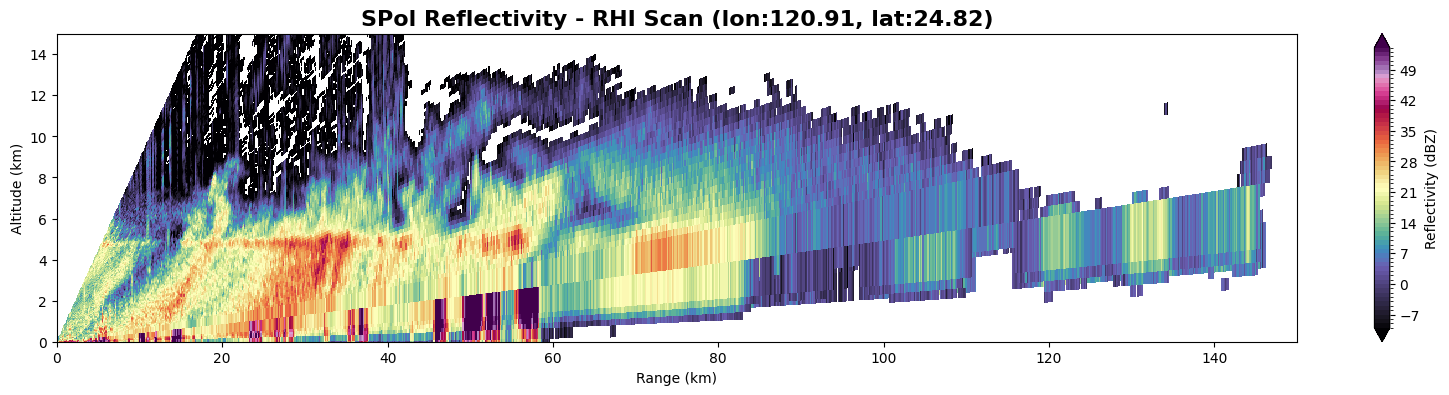

In [9]:
import matplotlib.pyplot as plt
import cmweather # colorblind friendly weather data visualization (https://cmweather.readthedocs.io/)

# plot DBZ with range and RHI altitude
fig, ax = plt.subplots(figsize=(20, 4))
ds_vertical_sweep0.DBZ.plot.pcolormesh(x='range', y='rhi_alt', cmap="ChaseSpectral", levels=np.arange(-10, 55, 1), ax=ax,add_colorbar=False)
ax.set_xlabel("Range (km)")
ax.set_ylabel("Altitude (km)")
ax.set_title(f"SPol Reflectivity - RHI Scan (lon:{ds_vertical_sweep0.longitude.values:0.2f}, lat:{ds_vertical_sweep0.latitude.values:0.2f})", fontsize=16, fontweight='bold')
ax.set_ylim(0,15)
ax.set_xlim(0,150)
plt.colorbar(ax.collections[0], ax=ax, label="Reflectivity (dBZ)")


## Step 6 - Visualize the SUR Scan

This step visualizes the horizontal PPI (Plan Position Indicator) scan using `xradar` georeferencing utilities. The following three cells:

1. **Georeference the DataTree** — uses `xradar.georeference` to compute Cartesian `x`, `y`, `z` coordinates from the radar's polar coordinates (range, azimuth, elevation), then extracts `sweep_0` as a `Dataset`.
2. **Plot in Cartesian coordinates** — renders the reflectivity field on a flat x/y grid (distance east vs. distance north in meters) using `matplotlib`.
3. **Plot on a geographic map** — reprojects the same reflectivity field onto a `cartopy` map with coastlines and gridlines, providing a geospatial context for the radar coverage area.


In [ ]:
import xradar as xd

### Utilize the xradar georeference utilities to get the x, y, z coordinates for the horizontal scan data.
dt_horizontal = dt_horizontal.xradar.georeference()
dt_horizontal = xd.georeference.get_x_y_z_tree(dt_horizontal)
ds_sweep_0 = dt_horizontal["sweep_0"].to_dataset()
da_dbz = ds_sweep_0["DBZ"]

In [14]:
da_dbz

<xarray.DataArray 'DBZ' (azimuth: 480, range: 1999)> Size: 4MB
[959520 values with dtype=float32]
Coordinates:
  * azimuth    (azimuth) float32 2kB 0.0 0.75 1.5 2.25 ... 357.8 358.5 359.2
  * range      (range) float32 8kB 75.0 225.0 375.0 ... 2.996e+05 2.998e+05
    altitude   float64 8B 10.0
    elevation  (azimuth) float32 2kB 0.4889 0.4889 0.4889 ... 0.4889 0.4889
    latitude   float64 8B 24.82
    longitude  float64 8B 120.9
    time       (azimuth) datetime64[ns] 4kB ...
    x          (azimuth, range) float64 8MB 0.0 0.0 ... -3.919e+03 -3.921e+03
    y          (azimuth, range) float64 8MB 75.0 225.0 ... 2.994e+05 2.995e+05
    z          (azimuth, range) float64 8MB 10.64 11.92 ... 7.844e+03 7.851e+03
    crs_wkt    int64 8B 0
Attributes:
    long_name:       DBZ
    standard_name:   DBZ
    units:           dBZ
    sampling_ratio:  1.0
    grid_mapping:    grid_mapping

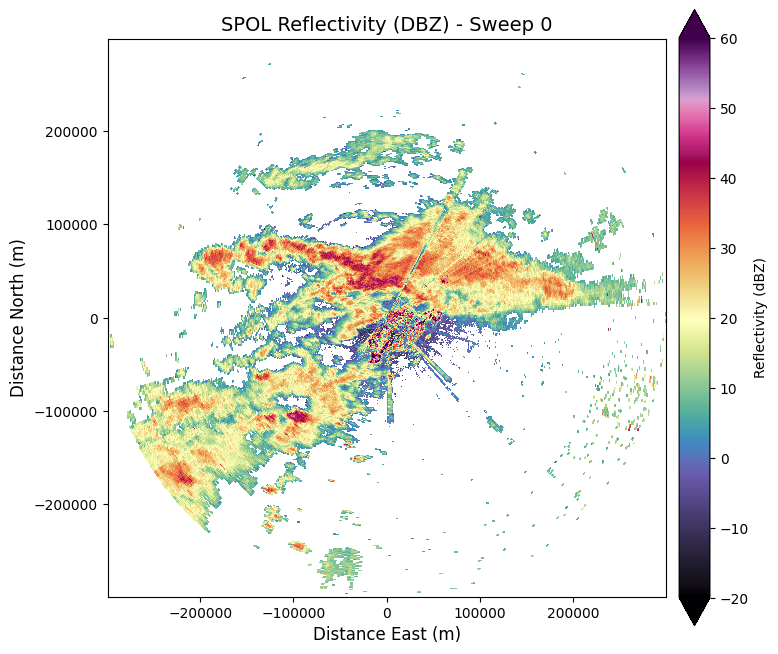

In [ ]:
#plot reflectivity field on a flat x/y grid 
fig, ax = plt.subplots(figsize=(8, 8))
pcm = da_dbz.plot(
    ax=ax,
    x="x",
    y="y",
    cmap="ChaseSpectral",
    vmin=-20,
    vmax=60,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Reflectivity (dBZ)",
        "shrink": 0.8,
        "pad": 0.02
    }
)

ax.set_title("SPOL Reflectivity (DBZ) - Sweep 0", fontsize=14)
ax.set_xlabel("Distance East (m)", fontsize=12)
ax.set_ylabel("Distance North (m)", fontsize=12)
ax.set_aspect("equal")  
ax.grid(False)
plt.tight_layout()
plt.show()

/glade/u/home/chiaweih/test_xradar/.venv/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)


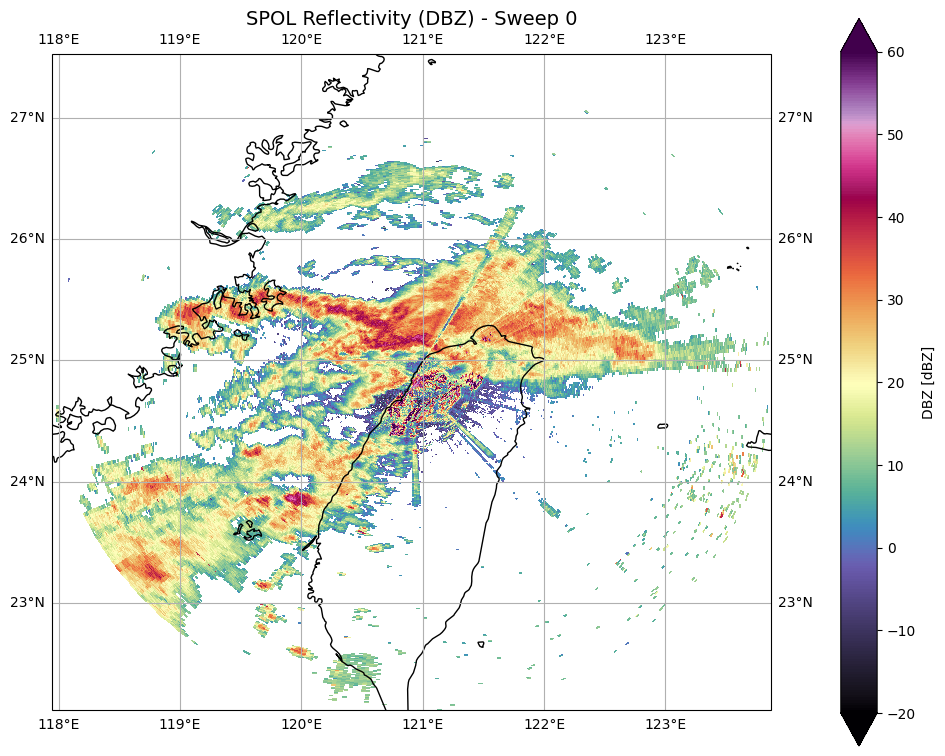

In [17]:
import cartopy
#Plot on geographic map
proj_crs = xd.georeference.get_crs(ds_sweep_0)
cart_crs = cartopy.crs.Projection(proj_crs)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=cartopy.crs.PlateCarree())
da_dbz.plot(
    x="x",
    y="y",
    cmap="ChaseSpectral",
    vmin=-20,
    vmax=60,
    transform=cart_crs,
    cbar_kwargs=dict(pad=0.075, shrink=0.75),
)
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_title("SPOL Reflectivity (DBZ) - Sweep 0", fontsize=14)
ax.set_aspect("equal")  
ax.grid(False)
plt.tight_layout()
plt.show()